## Import libraries
We import `nglview.color.ColormakerRegistry` so that we can make custom color schemes.

In [1]:
import procaliper as pc
import procaliper.view as pcv
from nglview.color import ColormakerRegistry
import matplotlib as plt

We create a colormaker registry object to store custom schemes

In [2]:
cm = ColormakerRegistry

## Download protein data

In [3]:
protein = pc.Protein.from_uniprot_id("P07900")
protein.fetch_pdb(save_path="scratch.pdb")

Fetched: 1 / 1


## Visualize pLDDT
First, we examine the pLDDT score for the AlphaFold structure we have fetched. We extract this using the `protein.get_confidence` method. These values fall between 0 and 100, and we rescale them to fall in the interval [0,1] for coloring. Since we have manually scaled these, we set `rescale=False`. Green and yellow regions indicate a lower confidence in local structure prediction. We can view the chosen color scale using `plt.colormaps.get_cmap("viridis_r")`.

In [4]:
_ = protein.get_confidence()  # extract pLDDT values from the PDB
assert protein.confidence_data is not None

pLDDT_scheme = pcv.ngl_scheme(
    [x / 100 for x in protein.confidence_data],
    color_mapper="viridis_r",
    rescale=False,
)  # create a color scheme from the pLDDT values

view = pcv.protein_to_nglview(protein)  # generate an nglview widget
view._remove_representation()  # remove the default representation

cm.add_selection_scheme(
    "all_pLDDT_value", pLDDT_scheme
)  # add our color scheme to nglview
view.add_representation(
    "ribbon", color="all_pLDDT_value"
)  # render the protein using our color scheme

view

NGLWidget()

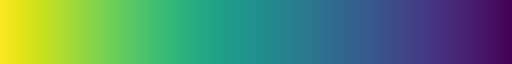

In [5]:
plt.colormaps.get_cmap("viridis_r")

## Visualize SASA
We compute the sasa data and assert that it was properly created. Then, we use the sasa values to create a color scheme and nglview widget using the `view` module of `procaliper`. We remove the default representation, register our created color scheme, and add the new representation with our color scheme.

In [6]:
_ = protein.get_sasa()  # compute and store sasa values at the site level
assert protein.sasa_data is not None

sasa_scheme = pcv.ngl_scheme(
    protein.sasa_data["all_sasa_value"]
)  # create a color scheme from the sasa values

view = pcv.protein_to_nglview(protein)  # generate an nglview widget
view._remove_representation()  # remove the default representation

cm.add_selection_scheme(
    "all_sasa_value", sasa_scheme
)  # add our color scheme to nglview
view.add_representation(
    "surface", color="all_sasa_value"
)  # render the protein using our color scheme

view

NGLWidget()

## Visualize Charge
We repeat the process with the charge values. The key difference here is that we pass `two_sided=True` to the `ngl_scheme` function to indicate that it should generate a two-sided color scheme (since charge can be either positive or negative).

In [7]:
_ = protein.get_charge()
assert protein.charge_data is not None
charges = [sum(x) for x in protein.charge_data["charge"]]
charge_scheme = pcv.ngl_scheme(
    charges,
    two_sided=True,
)

view = pcv.protein_to_nglview(protein)
view._remove_representation()
cm.add_selection_scheme("all_charge_value", charge_scheme)
view.add_representation("surface", color="all_charge_value")
view

NGLWidget()